## 1. Contexto y objetivo

Este proyecto analiza señales de vibración del dataset NASA IMS Bearings. El foco es entender si la señal cambia antes de la falla.

La idea es: tomar datos crudos de vibración, convertirlos en indicadores interpretables y revisar si esos indicadores muestran una transición desde una condición estable hacia una condición degradada.

La pregunta es:

**¿Existen indicadores derivados de la señal de vibración que muestren cambios progresivos antes del evento de falla?**

El análisis se mantiene exploratorio. Se prioriza interpretación, trazabilidad y conexión operacional por sobre complejidad de modelo.

## Preparación técnica

Se cargan las librerías principales, se definen las rutas del proyecto y se deja una opción para recuperar los datos procesados si el notebook se reinicia.

Esta sección es solo soporte técnico. El análisis comienza en la sección de datos.

In [ ]:
# Configuración base

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kurtosis

PROJECT_ROOT = Path.cwd().parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
SRC = PROJECT_ROOT / "src"

for path in [DATA_RAW, DATA_PROCESSED, OUTPUT_FIGURES, OUTPUT_TABLES, SRC]:
    path.mkdir(parents=True, exist_ok=True)

print("Configuración base lista.")

In [51]:
# Recuperar datos procesados si el notebook se reinicia

features_path = DATA_PROCESSED / "ims_features_1st_test_channel_5_bearing_3_with_band_energy.csv"

if features_path.exists():
    features_df = pd.read_csv(features_path)
    print("Datos procesados cargados:", features_df.shape)
else:
    print("Aún no existe tabla procesada. Ejecutar primero la extracción de indicadores.")

Datos procesados cargados: (2156, 16)


## 2. Datos utilizados

El análisis se acota al experimento `1st_test` del dataset NASA IMS Bearings. Cada archivo representa una captura de vibración en un momento específico del ensayo.

Se trabaja con el canal 5, asociado al Bearing 3. Esto permite seguir una línea clara: un sensor, una serie temporal y una evolución de indicadores.

Cada archivo contiene una matriz de señales. Las filas corresponden a muestras de vibración y las columnas a canales de medición.

In [5]:
# Resumen del dataset utilizado

dataset_summary = pd.DataFrame({
    "elemento": [
        "Dataset",
        "Experimento",
        "Cantidad de archivos",
        "Muestras por archivo",
        "Columnas / canales",
        "Canal analizado",
        "Rodamiento asociado"
    ],
    "valor": [
        "NASA IMS Bearings",
        "1st_test",
        2156,
        20480,
        8,
        "Canal 5",
        "Bearing 3"
    ]
})

dataset_summary

,elemento,valor
0,Dataset,NASA IMS Bearings
1,Experimento,1st_test
2,Cantidad de archivos,2156
3,Muestras por archivo,20480
4,Columnas / canales,8
5,Canal analizado,Canal 5
6,Rodamiento asociado,Bearing 3


**Lectura:** el experimento `1st_test` contiene 2.156 capturas ordenadas temporalmente. Cada archivo tiene 20.480 muestras y 8 canales de vibración. Para mantener el análisis simple, se trabaja con el canal 5, asociado al Bearing 3.

In [12]:
# Ruta del experimento a utilizar

data_path = DATA_RAW / "1st_test"

print("Ruta esperada del dataset:")
print(data_path)

print("\n¿Existe la carpeta?")
print(data_path.exists())

Ruta esperada del dataset:
C:\Users\benja\Desktop\IMS_Bearing_Project\data\raw\1st_test

¿Existe la carpeta?
True


In [13]:
# Listar archivos del experimento

files = sorted([file for file in data_path.iterdir() if file.is_file()])

print("Cantidad de archivos encontrados:", len(files))

print("\nPrimeros 3 archivos:")
for file in files[:3]:
    print(file.name)

print("\nÚltimos 3 archivos:")
for file in files[-3:]:
    print(file.name)

Cantidad de archivos encontrados: 2156

Primeros 3 archivos:
2003.10.22.12.06.24
2003.10.22.12.09.13
2003.10.22.12.14.13

Últimos 3 archivos:
2003.11.25.23.19.56
2003.11.25.23.29.56
2003.11.25.23.39.56


In [14]:
# Leer primer archivo como muestra

sample_file = files[0]

print("Archivo de muestra:")
print(sample_file.name)

df_sample = pd.read_csv(sample_file, sep=r"\s+", header=None)

df_sample.head()

Archivo de muestra:
2003.10.22.12.06.24


,0,1,2,3,4,5,6,7
0,-0.022,-0.039,-0.183,-0.054,-0.105,-0.134,-0.129,-0.142
1,-0.105,-0.017,-0.164,-0.183,-0.049,0.029,-0.115,-0.122
2,-0.183,-0.098,-0.195,-0.125,-0.005,-0.007,-0.171,-0.071
3,-0.178,-0.161,-0.159,-0.178,-0.100,-0.115,-0.112,-0.078
4,-0.208,-0.129,-0.261,-0.098,-0.151,-0.205,-0.063,-0.066


In [16]:
# Revisar tipos de datos

df_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 20480 entries, 0 to 20479
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       20480 non-null  float64
 1   1       20480 non-null  float64
 2   2       20480 non-null  float64
 3   3       20480 non-null  float64
 4   4       20480 non-null  float64
 5   5       20480 non-null  float64
 6   6       20480 non-null  float64
 7   7       20480 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [17]:
# Estadística descriptiva básica del archivo de muestra

df_sample.describe()

,0,1,2,3,4,5,6,7
count,20480.000000,20480.00000,20480.000000,20480.000000,20480.000000,20480.000000,20480.000000,20480.000000
mean,-0.094593,-0.09388,-0.093817,-0.093752,-0.090812,-0.090881,-0.090969,-0.094235
std,0.081124,0.07065,0.090650,0.077510,0.091463,0.095488,0.060086,0.066382
min,-0.720000,-0.56400,-0.674000,-0.530000,-0.496000,-0.784000,-0.413000,-0.471000
25%,-0.146000,-0.13900,-0.156000,-0.146000,-0.151000,-0.154000,-0.129000,-0.134000
50%,-0.095000,-0.09300,-0.093000,-0.093000,-0.090000,-0.090000,-0.090000,-0.095000
75%,-0.042000,-0.04900,-0.032000,-0.042000,-0.029000,-0.029000,-0.054000,-0.054000
max,0.388000,0.70100,0.359000,0.256000,0.400000,0.415000,0.249000,0.374000


In [20]:
# Seleccionar archivos representativos: inicio, mitad y final

first_file = files[0]
middle_file = files[len(files) // 2]
last_file = files[-1]

print("Archivo inicial:", first_file.name)
print("Archivo medio:", middle_file.name)
print("Archivo final:", last_file.name)

Archivo inicial: 2003.10.22.12.06.24
Archivo medio: 2003.11.15.18.18.46
Archivo final: 2003.11.25.23.39.56


**Cierre de sección:** el dataset queda organizado como una serie de capturas temporales de vibración. Cada archivo representa un momento del ensayo y contiene 20.480 muestras distribuidas en 8 canales.

Para el análisis se trabaja con el canal 5, asociado al Bearing 3. Esta decisión permite mantener una línea simple y trazable entre señal cruda, indicadores y evolución temporal.

## 3. Exploración de señales crudas

Primero se comparó tres momentos del experimento: inicio, mitad y final. Esta revisión ayuda a ver si la señal cambia visualmente.

Para mantener consistencia con el análisis, se trabaja con el canal 5, asociado al Bearing 3.

In [36]:
# Preparar señales crudas para comparación

first_file = files[0]
middle_file = files[len(files) // 2]
last_file = files[-1]

column_to_analyze = 4  # Canal 5 / Bearing 3

signal_first = load_signal(first_file, column=column_to_analyze)
signal_middle = load_signal(middle_file, column=column_to_analyze)
signal_last = load_signal(last_file, column=column_to_analyze)

signals = {
    "inicio": signal_first,
    "mitad": signal_middle,
    "final": signal_last
}

all_values = np.concatenate(list(signals.values()))
y_min = all_values.min()
y_max = all_values.max()

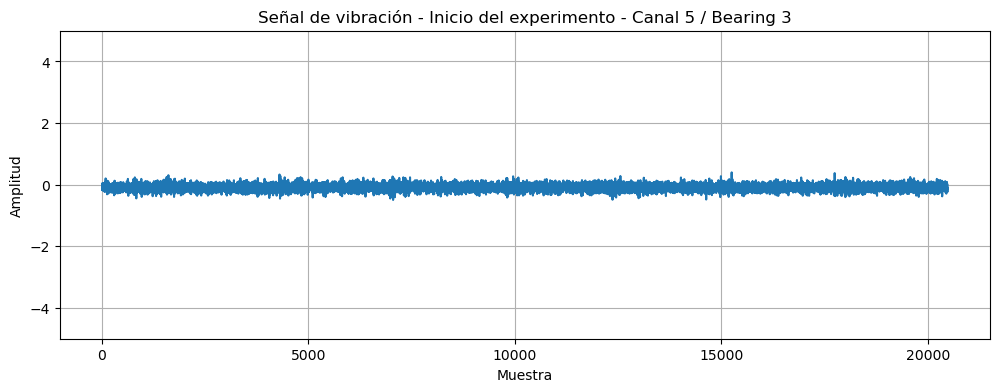

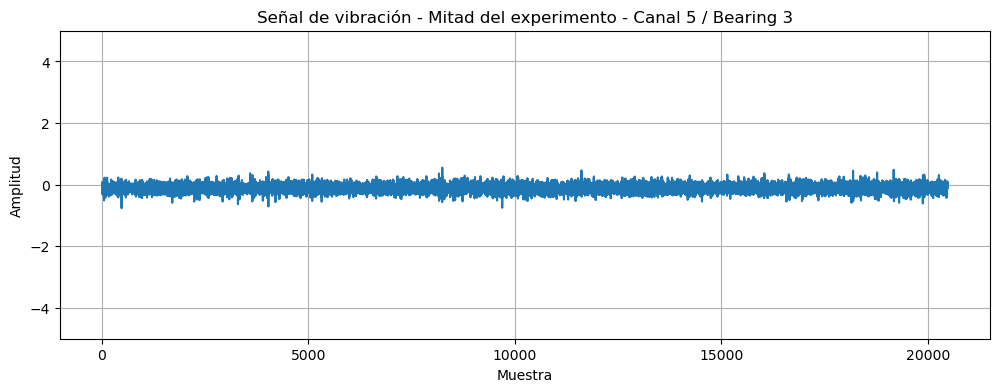

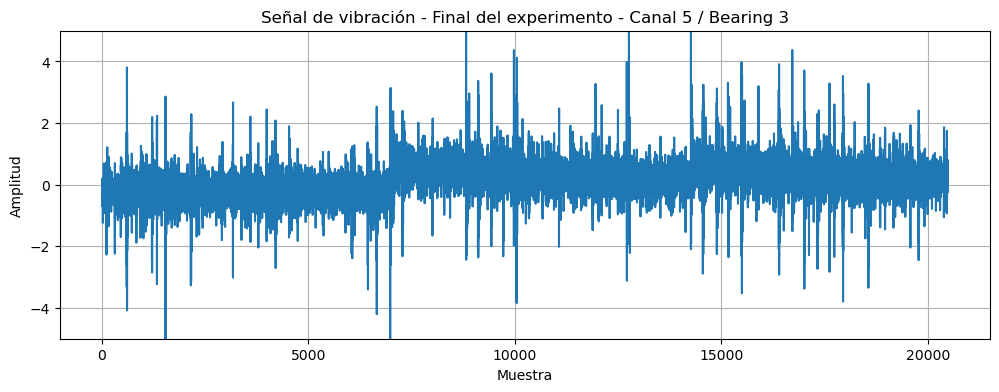

In [35]:
# Visualizar señales crudas con escala común

for momento, signal in signals.items():
    plt.figure(figsize=(12, 4))
    plt.plot(signal)
    plt.ylim(y_min, y_max)
    plt.title(f"Señal de vibración - {momento} del experimento - Canal 5 / Bearing 3")
    plt.xlabel("Muestra")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.show()

In [28]:
# Resumen rápido de amplitud para las tres señales

visual_summary = pd.DataFrame({
    "momento": ["inicio", "mitad", "final"],
    "archivo": [first_file.name, middle_file.name, last_file.name],
    "min": [signal_first.min(), signal_middle.min(), signal_last.min()],
    "max": [signal_first.max(), signal_middle.max(), signal_last.max()],
    "peak_to_peak": [
        signal_first.max() - signal_first.min(),
        signal_middle.max() - signal_middle.min(),
        signal_last.max() - signal_last.min()
    ],
    "std": [
        signal_first.std(),
        signal_middle.std(),
        signal_last.std()
    ]
})

visual_summary

,momento,archivo,min,max,peak_to_peak,std
0,inicio,2003.10.22.12.06.24,-0.496,0.400,0.896,0.091461
1,mitad,2003.11.15.18.18.46,-0.764,0.552,1.316,0.114227
2,final,2003.11.25.23.39.56,-5.000,4.998,9.998,0.579418


**Lectura:** la señal final muestra una amplitud y variabilidad mayor que las señales de inicio y mitad. También aparecen peaks más marcados, lo que sugiere un cambio claro en el comportamiento vibracional.

Esta comparación sigue siendo cualitativa. Sirve como primera evidencia visual, pero no basta por sí sola para hablar de degradación. Por eso, el siguiente paso es transformar cada archivo en indicadores numéricos comparables en el tiempo.

## 4. Extracción de indicadores

Cada archivo de vibración se transformó en una fila resumen. Para eso, se calcularon indicadores: RMS, desviación estándar, máximo absoluto y kurtosis.

Esta transformación reduce miles de puntos por archivo a variables comparables en el tiempo. El objetivo es dejar de mirar señales aisladas y empezar a observar evolución.

Los indicadores usados son:
- **RMS:** resume el nivel energético general de la vibración.
- **Desviación estándar:** mide la variabilidad de la señal.
- **Máximo absoluto:** identifica peaks de mayor amplitud.
- **Kurtosis:** ayuda a detectar impulsos o peaks bruscos.

In [ ]:
# Validación de variables necesarias para el Bloque 5

required_variables = ["files", "load_signal", "column_to_analyze", "DATA_PROCESSED"]

for var in required_variables:
    if var not in globals():
        raise NameError(
            f"La variable o función '{var}' no está definida. "
            "Ejecuta primero las celdas de preparación, listado de archivos y Bloque 4."
        )

print("Variables base disponibles. Se puede continuar con el Bloque 5.")
print("Cantidad de archivos:", len(files))
print("Columna/canal seleccionado:", column_to_analyze)
print("Carpeta de salida:", DATA_PROCESSED)

In [31]:
def calculate_features(signal):
    """
    Calcula indicadores estadísticos simples sobre una señal de vibración.

    Parámetros:
    - signal: arreglo numpy con la señal de vibración.

    Retorna:
    - diccionario con indicadores calculados.
    """
    rms = np.sqrt(np.mean(signal**2))
    std = np.std(signal)
    max_abs = np.max(np.abs(signal))
    kurt = kurtosis(signal)
    
    return {
        "rms": rms,
        "std": std,
        "max_abs": max_abs,
        "kurtosis": kurt
    }

In [37]:
# Procesar todos los archivos del experimento

features_list = []

for i, file_path in enumerate(files):
    signal = load_signal(file_path, column=column_to_analyze)
    features = calculate_features(signal)
    
    features["file"] = file_path.name
    features["time_index"] = i
    features["channel"] = column_to_analyze
    features["bearing"] = "Bearing 3"
    
    features_list.append(features)

features_df = pd.DataFrame(features_list)

features_df.head()

,rms,std,max_abs,kurtosis,file,time_index,channel,bearing
0,0.128887,0.091461,0.496,0.405439,2003.10.22.12.06.24,0,4,Bearing 3
1,0.129562,0.091732,0.566,0.445718,2003.10.22.12.09.13,1,4,Bearing 3
2,0.131339,0.091813,0.601,0.389712,2003.10.22.12.14.13,2,4,Bearing 3
3,0.131083,0.092385,0.552,0.261962,2003.10.22.12.19.13,3,4,Bearing 3
4,0.131307,0.091932,0.527,0.326192,2003.10.22.12.24.13,4,4,Bearing 3


In [39]:
# Ordenar columnas principales

features_df = features_df[
    [
        "file",
        "time_index",
        "channel",
        "bearing",
        "rms",
        "std",
        "max_abs",
        "kurtosis"
    ]
]

features_df.head()

,file,time_index,channel,bearing,rms,std,max_abs,kurtosis
0,2003.10.22.12.06.24,0,4,Bearing 3,0.128887,0.091461,0.496,0.405439
1,2003.10.22.12.09.13,1,4,Bearing 3,0.129562,0.091732,0.566,0.445718
2,2003.10.22.12.14.13,2,4,Bearing 3,0.131339,0.091813,0.601,0.389712
3,2003.10.22.12.19.13,3,4,Bearing 3,0.131083,0.092385,0.552,0.261962
4,2003.10.22.12.24.13,4,4,Bearing 3,0.131307,0.091932,0.527,0.326192


In [ ]:
# Validación básica de calidad

print("Valores nulos por columna:")
print(features_df.isna().sum())

print("\nValores infinitos en columnas numéricas:")
numeric_cols = ["rms", "std", "max_abs", "kurtosis"]
print(np.isinf(features_df[numeric_cols]).sum())

print("\nCantidad de filas:", len(features_df))
print("Cantidad de archivos originales:", len(files))

In [45]:
# Guardar tabla procesada

output_path = DATA_PROCESSED / "ims_features_1st_test_channel_5_bearing_3.csv"

features_df.to_csv(output_path, index=False)

print("Tabla guardada correctamente en:")
print(output_path)

Tabla guardada correctamente en:
C:\Users\benja\Desktop\IMS_Bearing_Project\data\processed\ims_features_1st_test_channel_5_bearing_3.csv


**Lectura:** la tabla resultante permite analizar el experimento como una serie temporal de indicadores. Cada fila representa una captura de vibración y cada columna resume un aspecto de la señal del canal 5 / Bearing 3.

**Cierre de sección:** los archivos crudos fueron convertidos en una tabla compacta de indicadores. Esta tabla permite pasar desde señales individuales de alta frecuencia hacia una lectura temporal más simple y comparable.

## 5. Evolución temporal de indicadores

Se revisa cómo evolucionan los indicadores calculados a lo largo del experimento. El objetivo es observar si existen cambios progresivos hacia el tramo final, no detectar automáticamente una falla.

Para mantener la lectura simple, se comparan los indicadores principales del canal 5 / Bearing 3: RMS, desviación estándar, máximo absoluto y kurtosis.

In [42]:
# Validar datos para evolución temporal

required_variables = ["features_df"]

for var in required_variables:
    if var not in globals():
        raise NameError(
            f"La variable '{var}' no está definida. "
            "Ejecuta la preparación técnica o carga la tabla procesada."
        )

required_columns = ["time_index", "rms", "std", "max_abs", "kurtosis"]

missing_columns = [col for col in required_columns if col not in features_df.columns]

if missing_columns:
    raise ValueError(f"Faltan columnas necesarias: {missing_columns}")

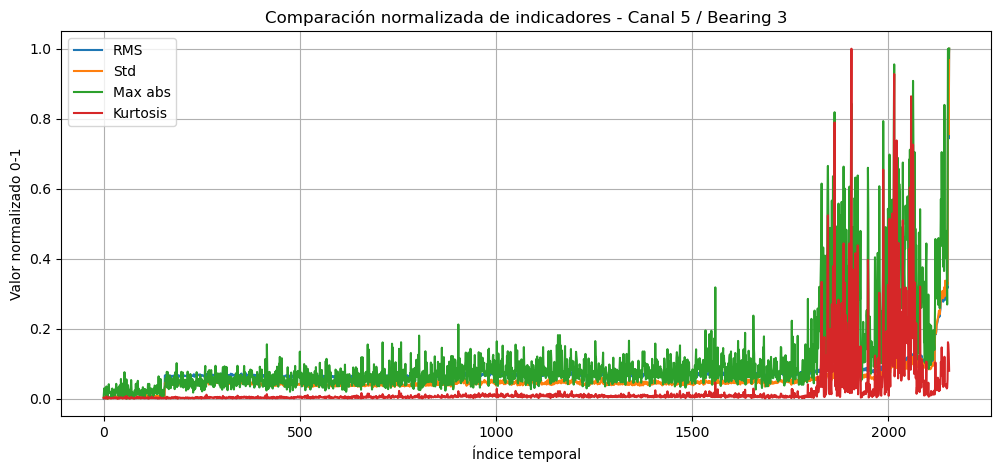

In [43]:
# Comparación normalizada de indicadores

features_norm = features_df.copy()

indicator_cols = ["rms", "std", "max_abs", "kurtosis"]

for col in indicator_cols:
    min_val = features_norm[col].min()
    max_val = features_norm[col].max()
    features_norm[col + "_norm"] = (
        (features_norm[col] - min_val) / (max_val - min_val)
    )

plt.figure(figsize=(12, 5))

plt.plot(features_norm["time_index"], features_norm["rms_norm"], label="RMS")
plt.plot(features_norm["time_index"], features_norm["std_norm"], label="Std")
plt.plot(features_norm["time_index"], features_norm["max_abs_norm"], label="Max abs")
plt.plot(features_norm["time_index"], features_norm["kurtosis_norm"], label="Kurtosis")

plt.title("Comparación normalizada de indicadores - Canal 5 / Bearing 3")
plt.xlabel("Índice temporal")
plt.ylabel("Valor normalizado 0-1")
plt.legend()
plt.grid(True)
plt.show()

**Lectura:** los indicadores no reaccionan igual. RMS y desviación estándar muestran una tendencia más progresiva, mientras que máximo absoluto y kurtosis responden con peaks más abruptos.

En conjunto, los indicadores muestran un cambio claro hacia el tramo final del experimento. Esto sugiere una transición desde un comportamiento más estable hacia una condición vibracional más irregular.

### Zona crítica exploratoria

Para ordenar la lectura temporal, se marca el último 20% del experimento como zona cercana a falla. Esta separación no representa el inicio exacto de la degradación; solo funciona como referencia visual.

La idea es observar si los indicadores aumentan antes o durante esa zona.

In [44]:
# Definir zona crítica exploratoria

critical_start = int(len(features_df) * 0.8)
critical_start

1724

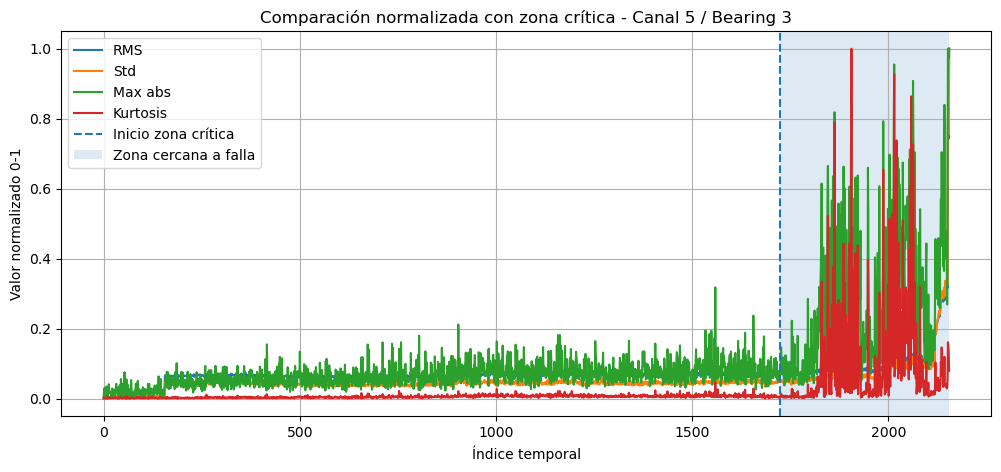

In [45]:
# Comparación normalizada con zona crítica

plt.figure(figsize=(12, 5))

plt.plot(features_norm["time_index"], features_norm["rms_norm"], label="RMS")
plt.plot(features_norm["time_index"], features_norm["std_norm"], label="Std")
plt.plot(features_norm["time_index"], features_norm["max_abs_norm"], label="Max abs")
plt.plot(features_norm["time_index"], features_norm["kurtosis_norm"], label="Kurtosis")

plt.axvline(
    x=critical_start,
    linestyle="--",
    label="Inicio zona crítica"
)

plt.axvspan(
    critical_start,
    features_norm["time_index"].max(),
    alpha=0.15,
    label="Zona cercana a falla"
)

plt.title("Comparación normalizada con zona crítica - Canal 5 / Bearing 3")
plt.xlabel("Índice temporal")
plt.ylabel("Valor normalizado 0-1")
plt.legend()
plt.grid(True)
plt.show()

**Lectura:** al marcar la zona crítica, se observa que varios indicadores aumentan con mayor fuerza hacia el tramo final. RMS y desviación estándar muestran una subida más progresiva, mientras que máximo absoluto y kurtosis concentran peaks más marcados.

Esta zona no debe interpretarse como una etiqueta operacional exacta de falla. Se usa solo como referencia exploratoria para evaluar la evolución de los indicadores.

### Suavizado de indicadores

Para reducir ruido visual, se aplica un promedio móvil de 10 archivos. El suavizado no detecta automáticamente la falla, pero ayuda a observar mejor la tendencia general.

El objetivo es distinguir entre peaks aislados y cambios más sostenidos en el tiempo.

In [47]:
# Crear indicadores suavizados

rolling_window = 10

features_df["rms_smooth"] = features_df["rms"].rolling(window=rolling_window).mean()
features_df["std_smooth"] = features_df["std"].rolling(window=rolling_window).mean()
features_df["max_abs_smooth"] = features_df["max_abs"].rolling(window=rolling_window).mean()
features_df["kurtosis_smooth"] = features_df["kurtosis"].rolling(window=rolling_window).mean()

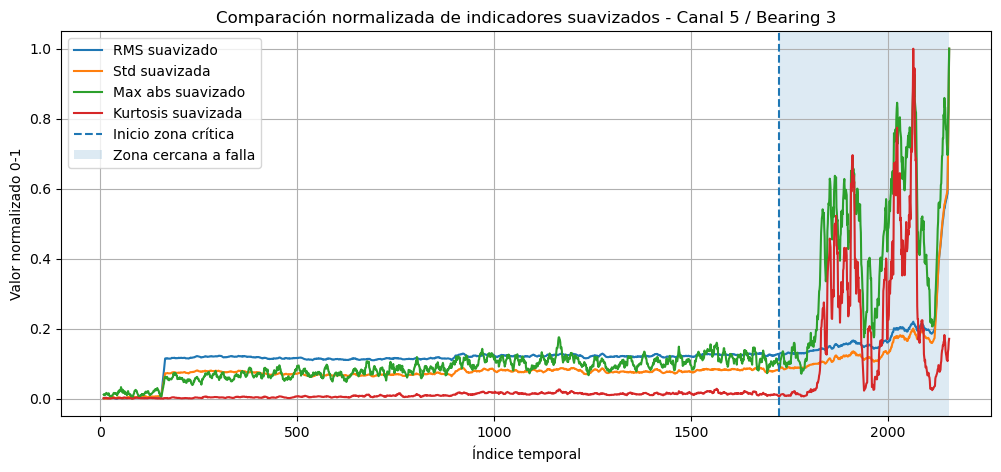

In [48]:
# Comparación normalizada de indicadores suavizados

smooth_cols = ["rms_smooth", "std_smooth", "max_abs_smooth", "kurtosis_smooth"]

features_smooth_norm = features_df.copy()

for col in smooth_cols:
    min_val = features_smooth_norm[col].min()
    max_val = features_smooth_norm[col].max()
    features_smooth_norm[col + "_norm"] = (
        (features_smooth_norm[col] - min_val) / (max_val - min_val)
    )

plt.figure(figsize=(12, 5))

plt.plot(
    features_smooth_norm["time_index"],
    features_smooth_norm["rms_smooth_norm"],
    label="RMS suavizado"
)

plt.plot(
    features_smooth_norm["time_index"],
    features_smooth_norm["std_smooth_norm"],
    label="Std suavizada"
)

plt.plot(
    features_smooth_norm["time_index"],
    features_smooth_norm["max_abs_smooth_norm"],
    label="Max abs suavizado"
)

plt.plot(
    features_smooth_norm["time_index"],
    features_smooth_norm["kurtosis_smooth_norm"],
    label="Kurtosis suavizada"
)

plt.axvline(
    x=critical_start,
    linestyle="--",
    label="Inicio zona crítica"
)

plt.axvspan(
    critical_start,
    features_smooth_norm["time_index"].max(),
    alpha=0.15,
    label="Zona cercana a falla"
)

plt.title("Comparación normalizada de indicadores suavizados - Canal 5 / Bearing 3")
plt.xlabel("Índice temporal")
plt.ylabel("Valor normalizado 0-1")
plt.legend()
plt.grid(True)
plt.show()

**Lectura:** el suavizado permite observar mejor la tendencia general de los indicadores. RMS y desviación estándar muestran un aumento más claro hacia el final, mientras que máximo absoluto y kurtosis siguen siendo más sensibles a peaks.

Este resultado refuerza la hipótesis exploratoria de una transición desde una condición relativamente estable hacia una condición degradada. Aun así, el suavizado no identifica por sí solo el inicio exacto de la falla; solo facilita la lectura temporal.

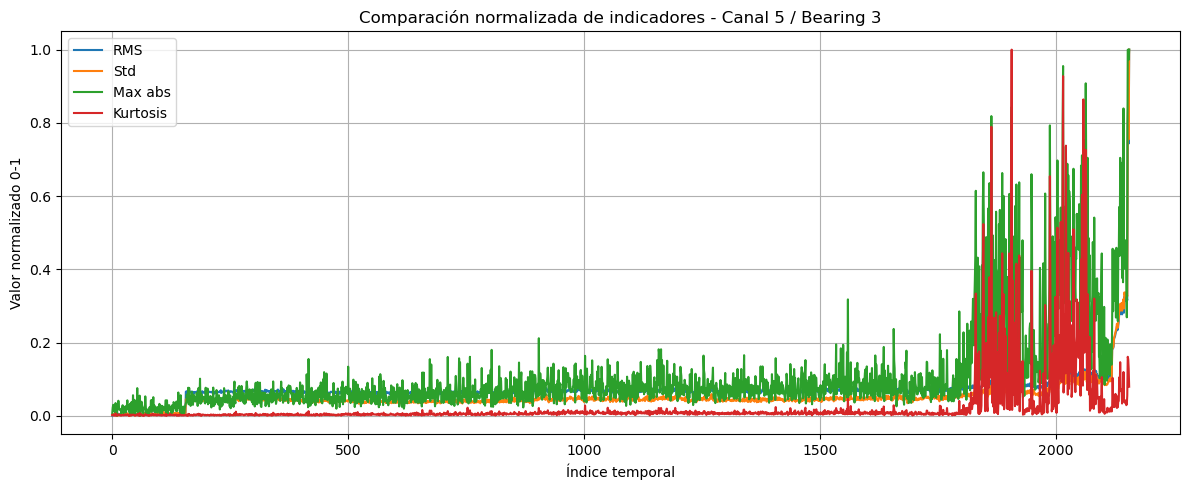

Gráfico guardado en:
C:\Users\benja\Desktop\IMS_Bearing_Project\outputs\figures\bloque_6_indicadores_normalizados_channel_5_bearing_3.png


In [60]:
# Guardar gráfico comparativo normalizado

figure_path = OUTPUT_FIGURES / "bloque_6_indicadores_normalizados_channel_5_bearing_3.png"

plt.figure(figsize=(12, 5))
plt.plot(features_norm["time_index"], features_norm["rms_norm"], label="RMS")
plt.plot(features_norm["time_index"], features_norm["std_norm"], label="Std")
plt.plot(features_norm["time_index"], features_norm["max_abs_norm"], label="Max abs")
plt.plot(features_norm["time_index"], features_norm["kurtosis_norm"], label="Kurtosis")

plt.title("Comparación normalizada de indicadores - Canal 5 / Bearing 3")
plt.xlabel("Índice temporal")
plt.ylabel("Valor normalizado 0-1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(figure_path, dpi=150)
plt.show()

print("Gráfico guardado en:")
print(figure_path)

**Cierre de sección:** los indicadores temporales muestran un cambio progresivo hacia el tramo final del experimento. La comparación normalizada y el suavizado permiten observar mejor esta transición sin depender de un solo indicador.

Este resultado justifica complementar el análisis con frecuencia, para revisar si el contenido espectral de la señal también cambia entre etapas del experimento.

## 6. Análisis en frecuencia

Hasta ahora el análisis se ha realizado principalmente en el dominio del tiempo, observando la evolución de indicadores como RMS, desviación estándar, máximo absoluto y kurtosis.

En esta sección se incorpora una revisión en el dominio de la frecuencia mediante FFT. La señal cruda muestra cómo varía la vibración en el tiempo, mientras que la FFT permite observar qué componentes de frecuencia están presentes.

El objetivo no es calcular frecuencias exactas de falla del rodamiento, sino comparar si el patrón espectral cambia entre el inicio, la mitad y el final del experimento.

In [ ]:
# Validación de señales necesarias para FFT

required_variables = [
    "signal_first",
    "signal_middle",
    "signal_last",
    "first_file",
    "middle_file",
    "last_file"
]

for var in required_variables:
    if var not in globals():
        raise NameError(
            f"La variable '{var}' no está definida. "
            "Ejecuta primero el Bloque 4, donde se cargan las señales de inicio, mitad y final."
        )

print("Señales disponibles para análisis FFT.")
print("Inicio:", signal_first.shape)
print("Mitad:", signal_middle.shape)
print("Final:", signal_last.shape)

In [54]:
# Frecuencia de muestreo del dataset IMS

sampling_rate = 20000  # Hz

print("Frecuencia de muestreo:", sampling_rate, "Hz")

Frecuencia de muestreo: 20000 Hz


In [53]:
def calculate_fft(signal, sampling_rate=20000):
    """
    Calcula la FFT de una señal de vibración.

    Parámetros:
    - signal: arreglo numpy con la señal en el tiempo.
    - sampling_rate: frecuencia de muestreo en Hz.

    Retorna:
    - frequencies: arreglo con frecuencias en Hz.
    - fft_magnitude: magnitud de la FFT.
    """
    n = len(signal)
    
    fft_values = np.fft.rfft(signal)
    fft_magnitude = np.abs(fft_values)
    frequencies = np.fft.rfftfreq(n, d=1 / sampling_rate)
    
    return frequencies, fft_magnitude

In [55]:
# Calcular FFT para señales representativas

freq_first, mag_first = calculate_fft(signal_first, sampling_rate=sampling_rate)
freq_middle, mag_middle = calculate_fft(signal_middle, sampling_rate=sampling_rate)
freq_last, mag_last = calculate_fft(signal_last, sampling_rate=sampling_rate)

print("FFT calculada correctamente.")
print("Frecuencias:", freq_first.shape)
print("Magnitud inicio:", mag_first.shape)
print("Magnitud mitad:", mag_middle.shape)
print("Magnitud final:", mag_last.shape)

FFT calculada correctamente.
Frecuencias: (10241,)
Magnitud inicio: (10241,)
Magnitud mitad: (10241,)
Magnitud final: (10241,)


In [56]:
# Límite de frecuencia para visualización

max_freq = 5000

print("Frecuencia máxima a visualizar:", max_freq, "Hz")

Frecuencia máxima a visualizar: 5000 Hz


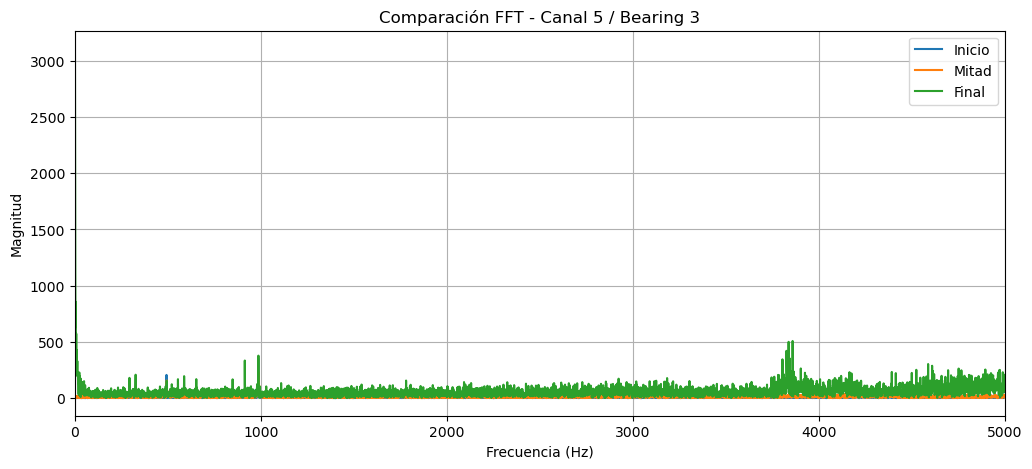

In [57]:
# Comparación FFT inicio, mitad y final

max_freq = 5000

plt.figure(figsize=(12, 5))

plt.plot(freq_first, mag_first, label="Inicio")
plt.plot(freq_middle, mag_middle, label="Mitad")
plt.plot(freq_last, mag_last, label="Final")

plt.xlim(0, max_freq)
plt.title("Comparación FFT - Canal 5 / Bearing 3")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.legend()
plt.grid(True)
plt.show()

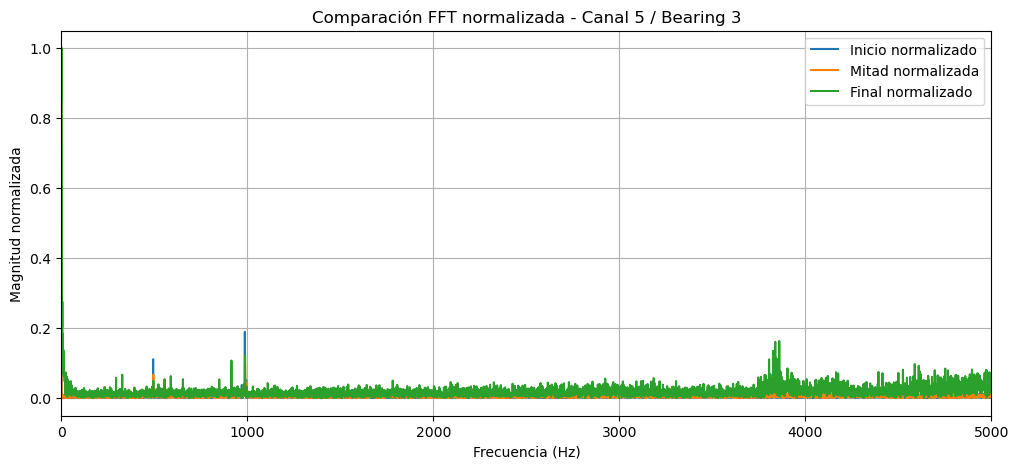

In [58]:
# Comparación FFT normalizada

mag_first_norm = mag_first / mag_first.max()
mag_middle_norm = mag_middle / mag_middle.max()
mag_last_norm = mag_last / mag_last.max()

plt.figure(figsize=(12, 5))

plt.plot(freq_first, mag_first_norm, label="Inicio normalizado")
plt.plot(freq_middle, mag_middle_norm, label="Mitad normalizada")
plt.plot(freq_last, mag_last_norm, label="Final normalizado")

plt.xlim(0, max_freq)
plt.title("Comparación FFT normalizada - Canal 5 / Bearing 3")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud normalizada")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Guardar gráfico FFT normalizado

fft_figure_path = OUTPUT_FIGURES / "bloque_9_fft_normalizada_channel_5_bearing_3.png"

plt.figure(figsize=(12, 5))

plt.plot(freq_first, mag_first_norm, alpha=0.7, label="Inicio normalizado")
plt.plot(freq_middle, mag_middle_norm, alpha=0.7, label="Mitad normalizado")
plt.plot(freq_last, mag_last_norm, alpha=0.7, label="Final normalizado")

plt.xlim(0, max_freq)
plt.title("Comparación FFT normalizada - Canal 5 / Bearing 3")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud normalizada")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(fft_figure_path, dpi=150)
plt.show()

print("Gráfico FFT guardado en:")
print(fft_figure_path)

### Interpretación del análisis FFT

El análisis en frecuencia permite comparar cómo se distribuye la energía de la señal entre distintas componentes espectrales. En este bloque se compararon tres capturas representativas del experimento: inicio, mitad y final.

La comparación muestra que la señal final presenta una magnitud espectral mayor que las señales inicial y media, lo que es coherente con el aumento de amplitud observado previamente en el dominio del tiempo. La versión normalizada permite comparar la forma relativa del espectro, reduciendo el efecto de las diferencias globales de amplitud.

Este análisis se utiliza como complemento del análisis temporal. No se busca identificar frecuencias exactas de falla del rodamiento, como BPFO o BPFI, porque eso requeriría un análisis específico de geometría del rodamiento, condiciones cinemáticas y frecuencias características. En esta etapa, la FFT se usa únicamente para observar si el patrón frecuencial cambia entre etapas del experimento.

En términos exploratorios, los resultados sugieren que hacia el final del ensayo no solo aumenta la amplitud de la señal, sino también su contenido energético en frecuencia. Esto refuerza la hipótesis de una transición desde una condición estable hacia una condición degradada.

## 7. Energía por bandas

Para resumir la información de la FFT, se calcula energía en rangos amplios de frecuencia. En lugar de observar espectros individuales, esta transformación permite seguir la evolución del contenido frecuencial a lo largo del experimento.

Las bandas se usan de forma exploratoria. No representan frecuencias exactas de falla del rodamiento, sino rangos simples para comparar cómo cambia la energía de la señal.

Las bandas utilizadas son:
- 0–500 Hz
- 500–1000 Hz
- 1000–3000 Hz
- 3000–5000 Hz

In [ ]:
# Bandas de frecuencia exploratorias

frequency_bands = {
    "energy_0_500": (0, 500),
    "energy_500_1000": (500, 1000),
    "energy_1000_3000": (1000, 3000),
    "energy_3000_5000": (3000, 5000)
}

frequency_bands

In [62]:
def calculate_band_energies(signal, sampling_rate=20000, bands=None):
    """
    Calcula energía espectral aproximada por bandas de frecuencia.

    Parámetros:
    - signal: arreglo numpy con la señal de vibración.
    - sampling_rate: frecuencia de muestreo en Hz.
    - bands: diccionario con nombre de banda y rango de frecuencias.

    Retorna:
    - diccionario con energía por banda.
    """
    if bands is None:
        bands = frequency_bands

    frequencies, magnitude = calculate_fft(signal, sampling_rate=sampling_rate)

    results = {}

    for band_name, (low, high) in bands.items():
        mask = (frequencies >= low) & (frequencies < high)
        results[band_name] = np.sum(magnitude[mask] ** 2)

    return results

In [70]:
# Calcular energía por bandas

energy_list = []

for i, file_path in enumerate(files):
    signal = load_signal(file_path, column=column_to_analyze)

    energy_features = calculate_band_energies(
        signal,
        sampling_rate=sampling_rate,
        bands=frequency_bands
    )

    energy_features["file"] = file_path.name
    energy_features["time_index"] = i
    energy_features["channel"] = column_to_analyze
    energy_features["bearing"] = "Bearing 3"

    energy_list.append(energy_features)

energy_df = pd.DataFrame(energy_list)

energy_df.head()

,energy_0_500,energy_500_1000,energy_1000_3000,energy_3000_5000,file,time_index,channel,bearing
0,3.568098e+06,263933.520183,203297.137286,313359.351717,2003.10.22.12.06.24,0,4,Bearing 3
1,3.619539e+06,264166.376874,212091.448398,314363.779011,2003.10.22.12.09.13,1,4,Bearing 3
2,3.800648e+06,258043.263043,204969.108215,323805.925804,2003.10.22.12.14.13,2,4,Bearing 3
3,3.734056e+06,258229.382353,215582.107548,308634.095960,2003.10.22.12.19.13,3,4,Bearing 3
4,3.796676e+06,251539.417013,207008.017926,319252.761148,2003.10.22.12.24.13,4,4,Bearing 3


In [72]:
# Unir energía por bandas con features_df

energy_cols = list(frequency_bands.keys())

cols_to_drop = [col for col in energy_cols if col in features_df.columns]

if cols_to_drop:
    features_df = features_df.drop(columns=cols_to_drop)

features_df = features_df.merge(
    energy_df[["file", "time_index"] + energy_cols],
    on=["file", "time_index"],
    how="left"
)

print("features_df actualizado:")
print(features_df.shape)

features_df.head()

features_df actualizado:
(2156, 16)


,file,time_index,channel,bearing,rms,std,max_abs,kurtosis,rms_smooth,std_smooth,max_abs_smooth,kurtosis_smooth,energy_0_500,energy_500_1000,energy_1000_3000,energy_3000_5000
0,2003.10.22.12.06.24,0,4,Bearing 3,0.128887,0.091461,0.496,0.405439,NaN,NaN,NaN,NaN,3.568098e+06,263933.520183,203297.137286,313359.351717
1,2003.10.22.12.09.13,1,4,Bearing 3,0.129562,0.091732,0.566,0.445718,NaN,NaN,NaN,NaN,3.619539e+06,264166.376874,212091.448398,314363.779011
2,2003.10.22.12.14.13,2,4,Bearing 3,0.131339,0.091813,0.601,0.389712,NaN,NaN,NaN,NaN,3.800648e+06,258043.263043,204969.108215,323805.925804
3,2003.10.22.12.19.13,3,4,Bearing 3,0.131083,0.092385,0.552,0.261962,NaN,NaN,NaN,NaN,3.734056e+06,258229.382353,215582.107548,308634.095960
4,2003.10.22.12.24.13,4,4,Bearing 3,0.131307,0.091932,0.527,0.326192,NaN,NaN,NaN,NaN,3.796676e+06,251539.417013,207008.017926,319252.761148


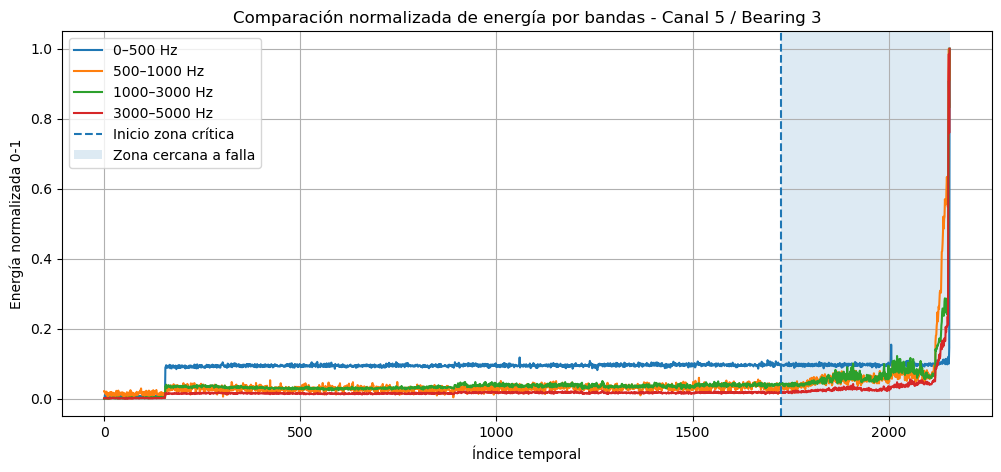

In [74]:
# Comparación normalizada de energía por bandas

energy_cols = [
    "energy_0_500",
    "energy_500_1000",
    "energy_1000_3000",
    "energy_3000_5000"
]

energy_norm = features_df.copy()

for col in energy_cols:
    min_val = energy_norm[col].min()
    max_val = energy_norm[col].max()
    energy_norm[col + "_norm"] = (energy_norm[col] - min_val) / (max_val - min_val)

plt.figure(figsize=(12, 5))

plt.plot(energy_norm["time_index"], energy_norm["energy_0_500_norm"], label="0–500 Hz")
plt.plot(energy_norm["time_index"], energy_norm["energy_500_1000_norm"], label="500–1000 Hz")
plt.plot(energy_norm["time_index"], energy_norm["energy_1000_3000_norm"], label="1000–3000 Hz")
plt.plot(energy_norm["time_index"], energy_norm["energy_3000_5000_norm"], label="3000–5000 Hz")

plt.axvline(
    x=critical_start,
    linestyle="--",
    label="Inicio zona crítica"
)

plt.axvspan(
    critical_start,
    energy_norm["time_index"].max(),
    alpha=0.15,
    label="Zona cercana a falla"
)

plt.title("Comparación normalizada de energía por bandas - Canal 5 / Bearing 3")
plt.xlabel("Índice temporal")
plt.ylabel("Energía normalizada 0-1")
plt.legend()
plt.grid(True)
plt.show()

In [130]:
# Guardar features_df actualizado con energía por bandas

features_energy_output_path = DATA_PROCESSED / "ims_features_1st_test_channel_5_bearing_3_with_band_energy.csv"

features_df.to_csv(features_energy_output_path, index=False)

print("Tabla con energía por bandas guardada en:")
print(features_energy_output_path)

Tabla con energía por bandas guardada en:
C:\Users\benja\Desktop\IMS_Bearing_Project\data\processed\ims_features_1st_test_channel_5_bearing_3_with_band_energy.csv


In [ ]:
# Guardar gráfico de comparación normalizada por bandas

band_energy_figure_path = OUTPUT_FIGURES / "bloque_10_energia_bandas_normalizada_channel_5_bearing_3.png"

plt.figure(figsize=(12, 5))

plt.plot(energy_norm["time_index"], energy_norm["energy_0_500_norm"], label="0–500 Hz")
plt.plot(energy_norm["time_index"], energy_norm["energy_500_1000_norm"], label="500–1000 Hz")
plt.plot(energy_norm["time_index"], energy_norm["energy_1000_3000_norm"], label="1000–3000 Hz")
plt.plot(energy_norm["time_index"], energy_norm["energy_3000_5000_norm"], label="3000–5000 Hz")

plt.axvline(
    x=critical_start,
    linestyle="--",
    label="Inicio zona crítica"
)

plt.axvspan(
    critical_start,
    energy_norm["time_index"].max(),
    alpha=0.15,
    label="Zona cercana a falla"
)

plt.title("Comparación normalizada de energía por bandas - Canal 5 / Bearing 3")
plt.xlabel("Índice temporal")
plt.ylabel("Energía normalizada 0-1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(band_energy_figure_path, dpi=150)
plt.show()

print("Gráfico guardado en:")
print(band_energy_figure_path)

### Interpretación de energía por bandas

La energía por bandas permite resumir el comportamiento frecuencial de cada archivo en indicadores comparables en el tiempo. Esto facilita observar si ciertas zonas del espectro aumentan hacia el tramo final del experimento.

En este análisis, las bandas se usan de forma exploratoria y no como frecuencias exactas de falla del rodamiento. El objetivo es comparar cómo evoluciona la energía espectral en rangos amplios.

El gráfico muestra un aumento claro de energía hacia la zona crítica, especialmente en bandas medias y altas. Esto complementa el análisis temporal y refuerza la hipótesis exploratoria de una transición desde una condición estable hacia una condición degradada.

## 8. Modelo exploratorio

Este modelo se usa solo como una prueba exploratoria. La idea no es construir un predictor productivo de falla, sino revisar si los indicadores calculados contienen información suficiente para separar una etapa inicial considerada normal de una etapa final considerada degradada.

La etiqueta utilizada no corresponde a una condición operacional real medida en terreno. Se define de forma aproximada:

- Primer 70% del experimento: normal
- Último 30% del experimento: degradado

Por lo tanto, el modelo debe interpretarse como apoyo exploratorio, no como una herramienta de predicción operacional.

In [75]:
# Validar datos para modelo exploratorio

required_cols = [
    "time_index",
    "rms",
    "std",
    "max_abs",
    "kurtosis",
    "energy_0_500",
    "energy_500_1000",
    "energy_1000_3000",
    "energy_3000_5000"
]

missing_cols = [col for col in required_cols if col not in features_df.columns]

if missing_cols:
    raise ValueError(f"Faltan columnas para el modelo: {missing_cols}")

In [76]:
# Crear etiqueta exploratoria

label_start = int(len(features_df) * 0.7)

features_df["label"] = np.where(
    features_df["time_index"] >= label_start,
    "degradado",
    "normal"
)

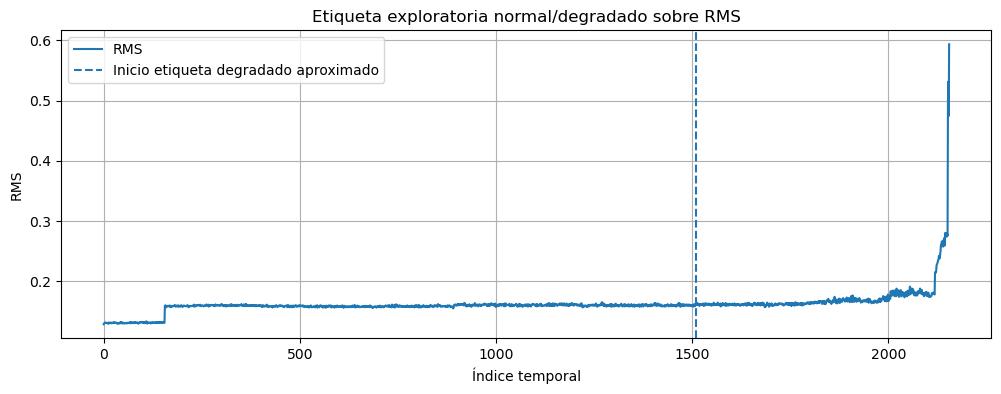

In [5]:
plt.figure(figsize=(12, 4))

plt.plot(
    features_df["time_index"],
    features_df["rms"],
    label="RMS"
)

plt.axvline(
    x=label_start,
    linestyle="--",
    label="Inicio etiqueta degradado aproximado"
)

plt.title("Etiqueta exploratoria normal/degradado sobre RMS")
plt.xlabel("Índice temporal")
plt.ylabel("RMS")
plt.legend()
plt.grid(True)
plt.show()

**Lectura:** la etiqueta normal/degradado se construye de forma aproximada usando el índice temporal. Esta separación permite hacer una prueba simple de clasificación, pero no representa una etiqueta operacional real de falla.

In [ ]:
# Variables predictoras del modelo exploratorio

feature_columns = [
    "rms",
    "std",
    "max_abs",
    "kurtosis",
    "energy_0_500",
    "energy_500_1000",
    "energy_1000_3000",
    "energy_3000_5000"
]

missing_features = [col for col in feature_columns if col not in features_df.columns]

if missing_features:
    raise ValueError(f"Faltan variables para el modelo: {missing_features}")

print("Variables seleccionadas para el modelo:")
feature_columns

In [ ]:
# Preparar matriz de variables y etiqueta

model_df = features_df[feature_columns + ["label", "time_index", "file"]].copy()

# Validar nulos e infinitos
print("Nulos por columna:")
print(model_df[feature_columns].isna().sum())

print("\nInfinitos por columna:")
print(np.isinf(model_df[feature_columns]).sum())

# Eliminar filas problemáticas si existieran
model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df = model_df.dropna(subset=feature_columns + ["label"])

X = model_df[feature_columns]
y = model_df["label"]

print("Dimensiones X:", X.shape)
print("Dimensiones y:", y.shape)
print("\nDistribución de clases:")
print(y.value_counts())

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# División exploratoria entrenamiento/test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño test:", X_test.shape)
print("\nDistribución y_train:")
print(y_train.value_counts())
print("\nDistribución y_test:")
print(y_test.value_counts())

In [ ]:
# Entrenar modelo Random Forest exploratorio

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

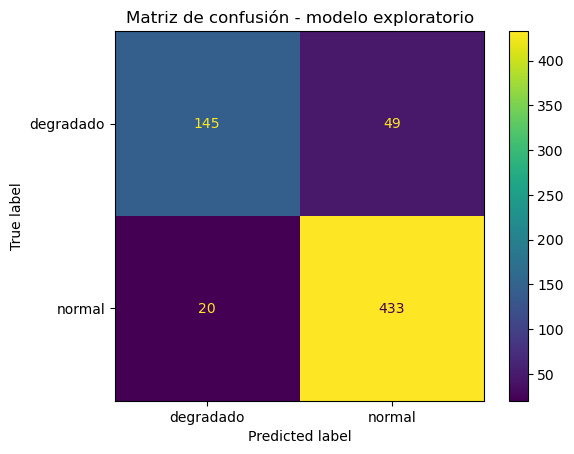

In [11]:
# Matriz de confusión

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Matriz de confusión - modelo exploratorio")
plt.show()

**Lectura:** la matriz de confusión muestra que el modelo logra separar razonablemente la etapa normal de la etapa degradada aproximada. Aun así, este resultado debe leerse con cautela, porque la etiqueta fue construida artificialmente a partir del tiempo.

In [ ]:
# Importancia de variables

importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df

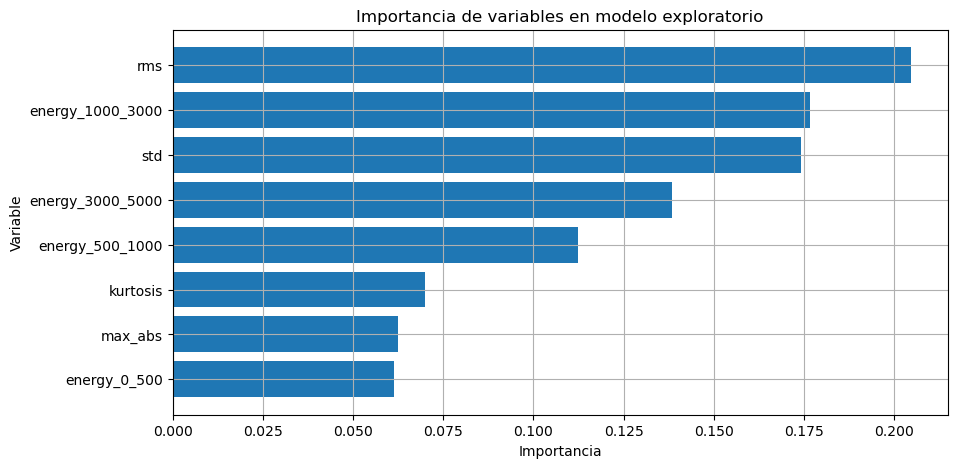

In [13]:
plt.figure(figsize=(10, 5))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.title("Importancia de variables en modelo exploratorio")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

In [ ]:
# Guardar importancia de variables

importance_path = OUTPUT_TABLES / "bloque_11_importancia_variables_modelo_exploratorio.csv"

importance_df.to_csv(importance_path, index=False)

print("Importancia de variables guardada en:")
print(importance_path)

In [ ]:
# Guardar gráfico de importancia

importance_figure_path = OUTPUT_FIGURES / "bloque_11_importancia_variables_modelo_exploratorio.png"

plt.figure(figsize=(10, 5))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.title("Importancia de variables en modelo exploratorio")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.savefig(importance_figure_path, dpi=150)
plt.show()

print("Gráfico de importancia guardado en:")
print(importance_figure_path)

In [ ]:
# Guardar tabla con etiqueta exploratoria

features_labeled_path = DATA_PROCESSED / "ims_features_1st_test_channel_5_bearing_3_labeled.csv"

features_df.to_csv(features_labeled_path, index=False)

print("Tabla con etiqueta exploratoria guardada en:")
print(features_labeled_path)

### Interpretación del modelo exploratorio

El modelo Random Forest se utilizó como una prueba exploratoria para revisar si los indicadores derivados de vibración permiten separar una etapa inicial considerada normal de una etapa final considerada degradada.

Los resultados no deben interpretarse como predicción real de falla. La etiqueta normal/degradado fue construida a partir del índice temporal del experimento, por lo que funciona solo como una referencia exploratoria.

La importancia de variables muestra que indicadores temporales y frecuenciales aportan información relevante para distinguir ambas etapas. Esto refuerza la idea central del proyecto: las señales crudas de vibración pueden transformarse en indicadores útiles para observar cambios de condición.

Como limitación metodológica, la división entrenamiento/test fue aleatoria. En una versión más rigurosa, la validación debería respetar el orden temporal del experimento, entrenando con una etapa inicial y evaluando sobre una etapa posterior.

## 9. Conclusión operacional

El análisis muestra que una señal cruda de vibración puede transformarse en indicadores simples capaces de describir la evolución del estado de un rodamiento.

Los resultados muestran cambios visuales en la señal hacia el tramo final del experimento. Estos cambios también aparecen en indicadores temporales como RMS, desviación estándar, máximo absoluto y kurtosis, además de variables frecuenciales como energía por bandas.

El valor operacional no está en detectar la falla cuando ya ocurrió, sino en observar cambios previos que permitan priorizar inspecciones, ajustar la frecuencia de monitoreo o planificar mantenimiento antes de una detención no programada.

Este enfoque es transferible a equipos rotatorios presentes en minería, como motores, bombas, ventiladores, correas transportadoras, chancadores y molinos. La clave no es partir con modelos complejos, sino construir una primera capa de indicadores interpretables para apoyar decisiones de confiabilidad.

## 10. Limitaciones y siguientes pasos

Este análisis es exploratorio. La etiqueta normal/degradado usada en el modelo fue definida a partir del tiempo y no desde una condición operacional medida directamente. Por eso, el modelo no debe interpretarse como un predictor real de falla.

Además, el estudio se acotó a un experimento y a un canal asociado al Bearing 3. Para una aplicación industrial sería necesario comparar múltiples canales, distintos experimentos y condiciones reales de operación.

Como siguiente paso, el análisis podría ampliarse usando validación temporal, umbrales basados en línea base y más información operacional, como carga, velocidad, historial de mantenimiento y condiciones de proceso.

Aun con estas limitaciones, el proyecto muestra una línea de trabajo útil: convertir señales de sensores en indicadores accionables para apoyar mantenimiento predictivo y decisiones de confiabilidad.